# Aula 7 — POD em Mecânica dos Fluidos
### PCA em snapshots de escoamento, modos POD, coeficientes temporais e energia modal

**Professor:** Prof. Dr. Rodrigo Figueiredo Abdo

*Curso: Fundamentos de Aprendizado de Máquina Científico para Mecânica dos Fluidos*

## Descrição

Este notebook **complementa** as notas da Aula 7. A **POD** (Proper Orthogonal Decomposition) é a
SVD aplicada a **snapshots** de campos: organizamos os estados do escoamento em colunas de uma
matriz $X\in\mathbb{R}^{n\times m}$, separamos média e flutuações, aplicamos SVD e lemos as colunas
de $U$ como **modos espaciais** $\boldsymbol\phi_j$, com **coeficientes temporais** $a_j(t)$ e
**energia modal** dada por $\sigma_j^2$.

Usaremos snapshots **sintéticos** de uma esteira oscilatória (sem arquivos externos) para ver o
par de modos em quadratura, a órbita circular dos coeficientes e a energia concentrada em poucos
modos. (Convenção: snapshots em **colunas**; modos POD são colunas de $U$.)

## Requisitos

| Biblioteca | Versão mínima | Finalidade |
|---|---|---|
| `numpy` | 1.22 | SVD, autovalores, normas |
| `matplotlib` | 3.5 | campos 2D, modos, coeficientes |

```bash
pip install numpy matplotlib
```

> Sem dependências opcionais e sem arquivos externos (os campos são gerados sinteticamente).

In [1]:
# --- Imports concentrados ---
import numpy as np
import matplotlib.pyplot as plt

# Fixamos a semente do gerador de números aleatórios: como mais adiante
# acrescentamos um pequeno ruído aos snapshots, a semente garante que o
# notebook produza sempre os MESMOS números a cada execução (reprodutível).
np.random.seed(42)

def energia_modal(s):
    '''Recebe os valores singulares 's' e devolve a energia de cada modo e a acumulada.

    Energia do modo j: E_j = sigma_j^2 / (soma de todos os sigma^2).
    Como os sigma vêm em ordem decrescente, np.cumsum soma da esquerda para a
    direita, dando a energia ACUMULADA pelos primeiros modos.'''
    e = s**2 / np.sum(s**2)        # fração de energia de cada modo (vetor)
    return e, np.cumsum(e)         # (energia por modo, energia acumulada)

print("Ambiente pronto.")

Ambiente pronto.


## Objetivos computacionais

1. Montar snapshots 2D, separar **média** e **flutuações** $X'$.
2. Obter **modos POD** ($U$), **coeficientes temporais** ($A=\Sigma V^T$) e **energia modal** por SVD.
3. Visualizar modos como campos e o **par oscilatório** (órbita circular dos coeficientes).
4. Reconstruir com $r$ modos; aplicar o **método dos snapshots**.
5. Reproduzir o exemplo algébrico das notas e discutir a limitação da **onda viajante**.

## 1. Snapshots, campo médio e flutuações

Geramos uma "esteira" sintética: um campo médio mais um **par oscilatório** de estruturas
espaciais deslocadas em fase. Cada coluna de $X$ é um snapshot (campo 2D achatado em vetor).

In [2]:
# Domínio espacial 2D (uma malha de nx por ny pontos) e o eixo do tempo (m instantes).
nx, ny, m = 64, 40, 80
xg = np.linspace(0, 4*np.pi, nx)     # nx posições ao longo de x
yg = np.linspace(-1.5, 1.5, ny)      # ny posições ao longo de y

# np.meshgrid pega os eixos 1D (xg, yg) e monta duas GRADES 2D: para cada ponto
# da malha, Xg guarda sua coordenada x e Yg guarda sua coordenada y.
# indexing="ij" faz a 1ª dimensão ser x e a 2ª ser y -> shape (nx, ny), na ordem
# "linha = x, coluna = y" (em vez do padrão "ij<->xy" do matplotlib).
Xg, Yg = np.meshgrid(xg, yg, indexing="ij")          # ambas com shape (nx, ny)

tg = np.linspace(0, 4*np.pi, m)      # m instantes de tempo
omega = 1.0                          # frequência da esteira oscilatória

# Montamos uma esteira sintética: um campo médio fixo MAIS um par de estruturas
# espaciais (phiA, phiB) que se alternam no tempo, gerando a oscilação.
envel = np.exp(-(Yg**2)/0.6)         # "envelope" que confina o padrão perto de y=0

# sin(xg) é um vetor 1D (só de x). O "[:, None]" acrescenta um segundo eixo (de
# tamanho 1), virando uma coluna (nx, 1); ao multiplicar por envel (nx, ny), o
# NumPy faz BROADCASTING: repete a coluna ao longo de y. Resultado: campo 2D.
phiA = np.sin(xg)[:, None] * envel              # estrutura espacial A, shape (nx, ny)
phiB = np.sin(xg + np.pi/2)[:, None] * envel    # estrutura B, deslocada 90 graus em x
campo_medio = 0.5*np.exp(-(Yg**2)/0.4)          # um "jato" médio, fixo no tempo

# Para cada instante t_k construímos um snapshot (campo 2D) e o guardamos.
# A combinação cos(t)*phiA + sin(t)*phiB faz o padrão "girar" entre A e B no tempo.
snaps = []
for tk in tg:
    campo = campo_medio + np.cos(omega*tk)*phiA + np.sin(omega*tk)*phiB
    campo += 0.02*np.random.randn(nx, ny)       # pequeno ruído (como num dado real)
    # .ravel() ACHATA o campo 2D (nx, ny) num único vetor coluna de n = nx*ny números:
    # é assim que um snapshot vira UMA coluna da matriz X.
    snaps.append(campo.ravel())

# snaps é uma lista de m vetores. np.array(snaps) os empilha como LINHAS (m, n);
# o ".T" (transposta) troca linhas por colunas para ficar (n, m): cada COLUNA é
# um snapshot. Esta é a convenção da POD: snapshots nas colunas de X.
X = np.array(snaps).T                            # matriz de snapshots, shape (n, m)
n = X.shape[0]                                   # n = nx*ny graus de liberdade espaciais
print("matriz de snapshots X:", X.shape, "(n = nx*ny =", n, ", m =", m, ")")

# Campo médio temporal: média de cada linha ao longo do tempo (eixo das colunas).
# keepdims=True mantém o resultado como coluna (n, 1) para subtrair de X por broadcasting.
u_bar = X.mean(axis=1, keepdims=True)            # campo médio, shape (n, 1)
Xp = X - u_bar                                   # matriz de flutuações X' = X - média
print("média das flutuações ~ 0 ?", np.allclose(Xp.mean(axis=1), 0, atol=1e-12))

matriz de snapshots X: (2560, 80) (n = nx*ny = 2560 , m = 80 )
média das flutuações ~ 0 ? True


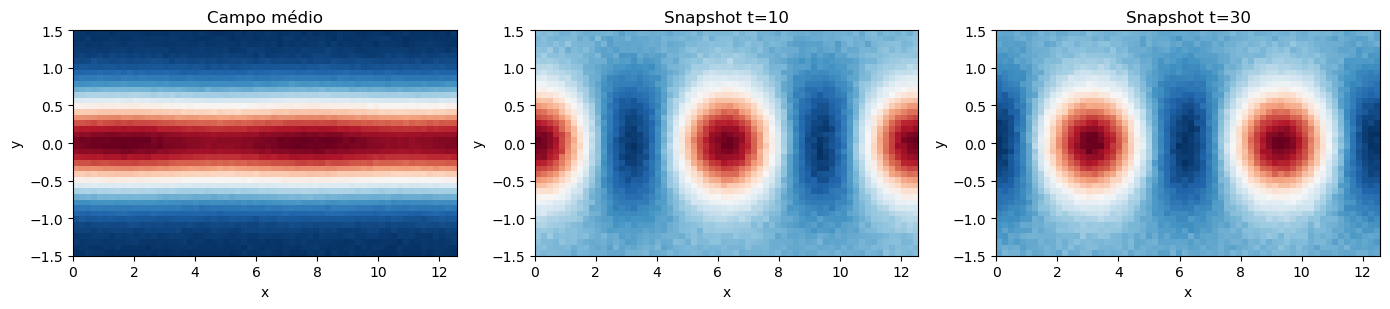

In [3]:
# Função auxiliar para DESENHAR um campo: ela aparece várias vezes adiante, então
# vale defini-la uma vez. Recebe um eixo (ax), o vetor achatado e um título.
def mostra_campo(ax, vetor, titulo):
    # O vetor tem n = nx*ny números. reshape(nx, ny) o reorganiza de volta na
    # malha 2D; o ".T" transpõe para que x fique no eixo horizontal e y no vertical
    # (imshow desenha "linha = y, coluna = x", o oposto da nossa convenção (nx, ny)).
    campo2d = vetor.reshape(nx, ny).T
    # origin="lower" põe a origem embaixo; extent fixa os limites reais dos eixos;
    # cmap="RdBu_r" usa azul/vermelho (bom para campos com sinal + e -).
    im = ax.imshow(campo2d, origin="lower", aspect="auto", cmap="RdBu_r",
                   extent=[xg[0], xg[-1], yg[0], yg[-1]])
    ax.set_title(titulo)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    return im

# Três painéis lado a lado: o campo médio e dois snapshots em instantes diferentes.
fig, axes = plt.subplots(1, 3, figsize=(14, 3.2))
mostra_campo(axes[0], u_bar[:, 0], "Campo médio")   # u_bar é (n, 1); [:, 0] pega a coluna como vetor
mostra_campo(axes[1], X[:, 10], "Snapshot t=10")    # coluna 10 de X = snapshot do instante 10
mostra_campo(axes[2], X[:, 30], "Snapshot t=30")    # coluna 30 de X = snapshot do instante 30
plt.tight_layout()
plt.show()

## 2. SVD dos snapshots de flutuação

$X'=U\Sigma V^T$. As colunas de $U$ são os modos POD; os coeficientes temporais são
$A=\Sigma V^T$ (linha $j$ = evolução do modo $j$).

In [4]:
# SVD das flutuações: X' = U @ diag(s) @ Vt. Usamos a função pronta do NumPy.
# full_matrices=False pede a SVD "econômica" (só as partes úteis), bem mais barata.
# - U   : colunas são os MODOS ESPACIAIS phi_j (cada coluna é um campo no espaço).
# - s   : valores singulares sigma_j (já em ordem decrescente).
# - Vt  : V transposta; suas LINHAS dão a evolução temporal normalizada dos modos.
U, s, Vt = np.linalg.svd(Xp, full_matrices=False)

# Coeficientes temporais A = Sigma @ V^T. np.diag(s) transforma o vetor s na matriz
# diagonal Sigma; multiplicar por Vt dá A, cuja LINHA j é a amplitude a_j(t) do modo j
# ao longo do tempo. (Modo espacial = coluna de U; coeficiente temporal = linha de A.)
A = np.diag(s) @ Vt                 # shape (r, m)

print("nº de valores singulares:", len(s))
print("4 maiores sigma:", np.round(s[:4], 3))
# Conferência: U @ Sigma @ Vt deve reconstruir exatamente X' (a SVD é uma igualdade).
print("reconstrução exata X' ?", np.allclose(U @ np.diag(s) @ Vt, Xp))

nº de valores singulares: 80
4 maiores sigma: [127.292 126.88    1.18    1.168]
reconstrução exata X' ? True


## 3. Modos POD como campos espaciais

Cada modo $\boldsymbol\phi_j$ (coluna de $U$) é um campo no domínio. Os **dois primeiros**
formam o par oscilatório da esteira (estruturas semelhantes, deslocadas em fase).

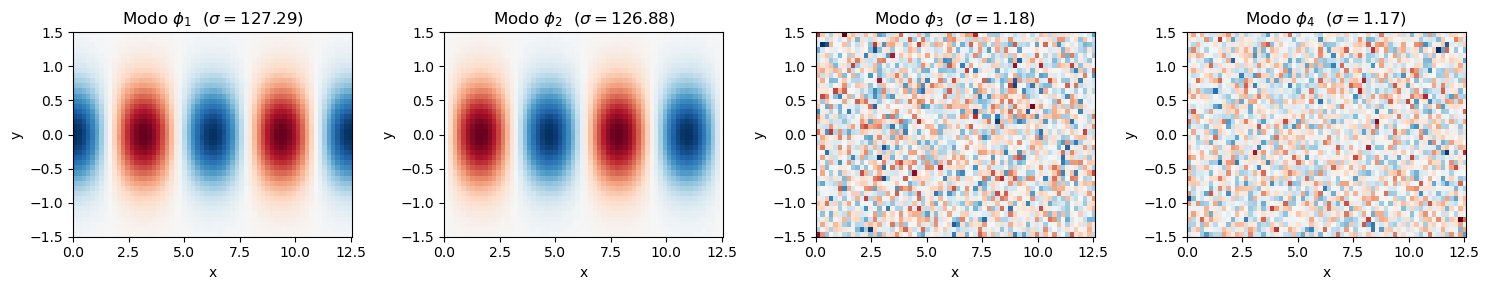

In [5]:
# Desenhamos os 4 primeiros modos POD, cada um reorganizado como um campo 2D.
# Cada modo é a coluna U[:, j]; usamos a mesma mostra_campo de antes.
fig, axes = plt.subplots(1, 4, figsize=(15, 3.0))

# enumerate(axes) percorre os painéis dando, a cada passo, o índice j (0,1,2,3)
# e o painel ax correspondente. Assim o modo j vai para o painel j.
for j, ax in enumerate(axes):
    # f"...{j+1}..." monta o título com o número do modo (1..4) e seu sigma.
    # As duas barras "\\phi" são para o LaTeX do título mostrar a letra phi.
    mostra_campo(ax, U[:, j], f"Modo $\\phi_{j+1}$  ($\\sigma={s[j]:.2f}$)")

plt.tight_layout()
plt.show()

## 4. Coeficientes temporais e a órbita $(a_1,a_2)$

Numa esteira periódica, $a_1(t)\sim\cos\omega t$ e $a_2(t)\sim\sin\omega t$ (defasados $90^\circ$):
no plano $(a_1,a_2)$ a trajetória é quase **circular** — assinatura de dinâmica 2D periódica.

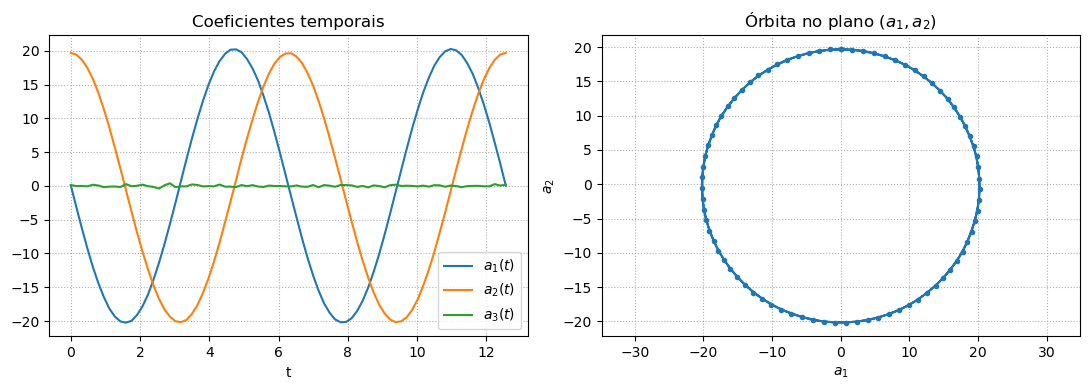

In [6]:
# Dois painéis: à esquerda as séries temporais a_j(t); à direita a órbita (a1, a2).
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Painel da esquerda: a evolução temporal dos 3 primeiros modos.
# Lembre que A[j, :] é a LINHA j de A, ou seja, a amplitude do modo j em todos
# os instantes. Plotamos a_1(t), a_2(t) e a_3(t).
for j in range(3):
    ax1.plot(tg, A[j, :], label=f"$a_{j+1}(t)$")
ax1.set_title("Coeficientes temporais")
ax1.set_xlabel("t")
ax1.legend()
ax1.grid(True, ls=":")

# Painel da direita: a trajetória no plano (a_1, a_2). Numa esteira periódica,
# a_1 ~ cos(wt) e a_2 ~ sin(wt) -> o par traça um círculo (dinâmica 2D periódica).
ax2.plot(A[0, :], A[1, :], "o-", ms=3)
ax2.set_title("Órbita no plano $(a_1, a_2)$")
ax2.set_xlabel("$a_1$")
ax2.set_ylabel("$a_2$")
ax2.axis("equal")            # mesma escala nos dois eixos, senão o círculo vira elipse
ax2.grid(True, ls=":")

plt.tight_layout()
plt.show()

## 5. Energia modal

$E_j=\sigma_j^2/\sum_\ell\sigma_\ell^2$. Como a esteira é dominada pelo par oscilatório, os **dois
primeiros** modos concentram quase toda a energia das flutuações.

modo 1: E_j = 0.5004 | acumulada = 0.5004
modo 2: E_j = 0.4972 | acumulada = 0.9976
modo 3: E_j = 0.0000 | acumulada = 0.9976
modo 4: E_j = 0.0000 | acumulada = 0.9976


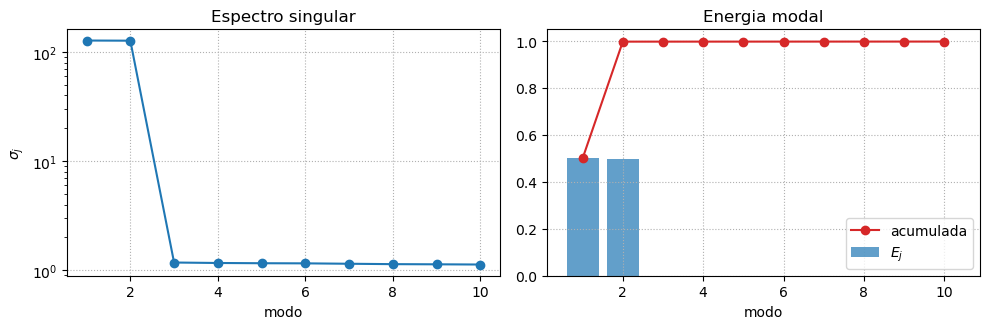

In [7]:
# Energia por modo (Ej) e energia acumulada, usando a função definida no setup.
Ej, Eacum = energia_modal(s)

# Imprimimos os 4 primeiros para conferir que os 2 primeiros já concentram quase tudo.
for j in range(4):
    print(f"modo {j+1}: E_j = {Ej[j]:.4f} | acumulada = {Eacum[j]:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.4))

# Painel da esquerda: espectro singular (sigma_j por modo). range(1, 11) gera os
# rótulos 1..10 no eixo x; semilogy usa escala log no eixo y, onde a queda
# acentuada dos sigma fica visível.
ax1.semilogy(range(1, 11), s[:10], "o-")
ax1.set_title("Espectro singular")
ax1.set_xlabel("modo")
ax1.set_ylabel(r"$\sigma_j$")
ax1.grid(True, ls=":")

# Painel da direita: barras = energia de cada modo (E_j); linha vermelha = energia
# acumulada (cresce até ~1, ou 100%, ao somar todos os modos).
ax2.bar(range(1, 11), Ej[:10], alpha=0.7, label=r"$E_j$")
ax2.plot(range(1, 11), Eacum[:10], "o-", color="tab:red", label="acumulada")
ax2.set_title("Energia modal")
ax2.set_xlabel("modo")
ax2.set_ylim(0, 1.05)
ax2.legend()
ax2.grid(True, ls=":")

plt.tight_layout()
plt.show()

## 6. Reconstrução com $r$ modos

$\mathbf{u}_k\approx\bar{\mathbf{u}}+\sum_{j=1}^r a_j(t_k)\boldsymbol\phi_j$. Com 2 modos já
recuperamos a oscilação dominante.

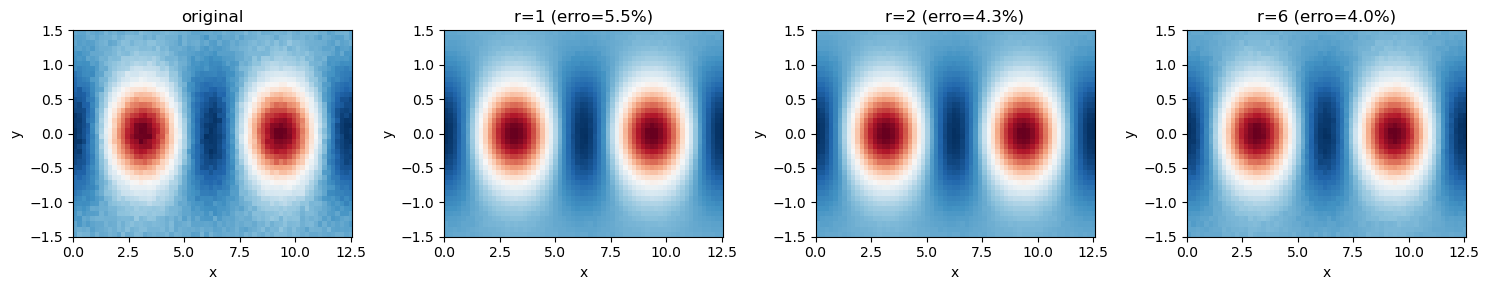

erro relativo das flutuações por r: [0.7068 0.0494 0.0489 0.0485 0.0481 0.0476 0.0472 0.0468 0.0463 0.0459]


In [8]:
# Reconstrução de um snapshot usando só os r primeiros modos:
#   u_k  ~=  media  +  soma_{j=1..r} a_j(t_k) * phi_j.
# U[:, :r] pega as r primeiras COLUNAS de U (os r modos); A[:r, k] pega as r
# primeiras LINHAS da coluna k de A (os r coeficientes daquele instante).
# O produto U[:, :r] @ A[:r, k] faz exatamente a soma acima, de uma vez.
def reconstroi(r, k):
    return u_bar[:, 0] + U[:, :r] @ A[:r, k]

# Comparamos o snapshot original (k=30) com reconstruções de posto crescente.
k = 30
fig, axes = plt.subplots(1, 4, figsize=(15, 3.0))
mostra_campo(axes[0], X[:, k], "original")

# zip(axes[1:], [1, 2, 6]) anda em paralelo nos 3 painéis restantes e nos valores
# de r (1, 2, 6): cada painel recebe uma reconstrução com aquele número de modos.
for ax, r in zip(axes[1:], [1, 2, 6]):
    # Erro relativo: norma da diferença dividida pela norma do snapshot original.
    erro = np.linalg.norm(reconstroi(r, k) - X[:, k]) / np.linalg.norm(X[:, k])
    mostra_campo(ax, reconstroi(r, k), f"r={r} (erro={erro:.1%})")
plt.tight_layout()
plt.show()

# Erro global de reconstrução das FLUTUAÇÕES para cada r de 1 a 10.
# Esta "list comprehension" é um for compacto: para cada r, calcula o erro relativo
# (norma de Frobenius da diferença / norma de X') e guarda numa lista.
erros = [np.linalg.norm(Xp - U[:, :r] @ A[:r, :], 'fro') / np.linalg.norm(Xp, 'fro')
         for r in range(1, 11)]
print("erro relativo das flutuações por r:", np.round(erros, 4))

## 7. Método dos snapshots ($n\gg m$)

Em vez de $X'X'^T$ ($n\times n$), resolvemos $C_t=X'^TX'$ ($m\times m$): seus autovalores são
$\sigma_j^2$ e os modos saem de $\boldsymbol\phi_j=X'\mathbf{v}_j/\sigma_j$.

In [9]:
# Método dos snapshots: em vez do autoproblema gigante X'X'^T (n x n), resolvemos
# o pequeno C_t = X'^T X' (m x m). Aqui m=80 << n=2560, então é muito mais barato.
Ct = Xp.T @ Xp                          # matriz de correlação temporal, shape (m, m)

# np.linalg.eigh resolve o autoproblema de uma matriz simétrica e devolve os
# autovalores em ordem CRESCENTE. Precisamos deles em ordem decrescente.
vals, vecs = np.linalg.eigh(Ct)         # vals crescente; vecs nas colunas

# np.argsort(vals) dá os índices que ordenam vals do menor para o maior; o "[::-1]"
# inverte essa lista, ficando do maior para o menor. Reordenamos vals e vecs por ela.
idx = np.argsort(vals)[::-1]            # índices que põem os autovalores em ordem decrescente
vals, vecs = vals[idx], vecs[:, idx]

# Os autovalores de C_t são sigma_j^2. np.clip(..., 0, None) zera eventuais
# valores levemente negativos (erro numérico) antes da raiz quadrada.
sigma_sn = np.sqrt(np.clip(vals, 0, None))
print("sigma (método dos snapshots) vs SVD (4 maiores):")
print("  snapshots:", np.round(sigma_sn[:4], 4))
print("  SVD      :", np.round(s[:4], 4))

# Recuperamos um modo espacial pela fórmula phi_j = X' v_j / sigma_j.
# Ele deve coincidir com a coluna de U a menos do SINAL (modos POD não têm sinal único).
phi1 = Xp @ vecs[:, 0] / sigma_sn[0]
alinhado = np.allclose(phi1, U[:, 0]) or np.allclose(phi1, -U[:, 0])
print("phi_1 do método dos snapshots == coluna de U (a menos de sinal)?", alinhado)

sigma (método dos snapshots) vs SVD (4 maiores):
  snapshots: [127.2924 126.8797   1.1796   1.1681]
  SVD      : [127.2924 126.8797   1.1796   1.1681]
phi_1 do método dos snapshots == coluna de U (a menos de sinal)? True


## 8. Exemplo algébrico das notas (Seção 8)

$\boldsymbol\phi_1=\frac1{\sqrt2}(1,1,0,0)$, $\boldsymbol\phi_2=\frac1{\sqrt2}(0,0,1,-1)$ com
$\mathbf{a}_1=(2,0,-2,0)$, $\mathbf{a}_2=(0,1,0,-1)$ ⇒ $\sigma_1=2\sqrt2$, $\sigma_2=\sqrt2$,
$E_1=0.8$.

In [10]:
# Reproduzimos o exemplo algébrico das notas (Seção 8), com modos e coeficientes dados.
r2 = np.sqrt(2)
phi1 = np.array([1, 1, 0, 0]) / r2       # modo espacial 1 (ortonormal)
phi2 = np.array([0, 0, 1, -1]) / r2      # modo espacial 2 (ortonormal)
a1 = np.array([2, 0, -2, 0.0])           # coeficientes temporais do modo 1
a2 = np.array([0, 1, 0, -1.0])           # coeficientes temporais do modo 2

# np.outer(phi, a) é o produto externo: uma matriz onde a coluna k é a*[k] * phi
# (posto 1). Somando os dois, montamos X' = phi1 a1^T + phi2 a2^T exatamente como nas notas.
Xp_ex = np.outer(phi1, a1) + np.outer(phi2, a2)

# Aqui a SVD não é "feita à mão": pedimos só os valores singulares à biblioteca
# (compute_uv=False não calcula U nem V, devolvendo apenas os sigma).
s_ex = np.linalg.svd(Xp_ex, compute_uv=False)
print("sigma:", np.round(s_ex[:2], 4), "(esperado 2*sqrt(2) =", round(2*r2,4), ", sqrt(2) =", round(r2,4), ")")

# s_ex > 1e-10 é uma máscara booleana que descarta os sigma essencialmente nulos
# (a matriz tem posto 2), ficando só com os modos de energia real.
Ej_ex, _ = energia_modal(s_ex[s_ex > 1e-10])
print("E_1, E_2:", np.round(Ej_ex[:2], 3), "(esperado 0.8 e 0.2)")

sigma: [2.8284 1.4142] (esperado 2*sqrt(2) = 2.8284 , sqrt(2) = 1.4142 )
E_1, E_2: [0.8 0.2] (esperado 0.8 e 0.2)


## 9. Limitação: estruturas que se deslocam

Uma estrutura **localizada** que apenas se desloca (um pulso convectado) tem **posto alto** na
POD: a SVD precisa de muitos modos para representar a translação de um padrão fixo. Comparamos com
uma oscilação **estacionária** (separável, posto ~1). *Observação:* uma onda senoidal pura
$\sin(k(x-ct))$ é o caso especial de **posto 2** (vira $\sin kx\cos ct-\cos kx\sin ct$); a
dificuldade aparece para estruturas localizadas, como abaixo.

pulso viajante: nº de sigma > 1% do máximo = 19 (posto alto)
oscilação estacionária: nº de sigma > 1% do máximo = 1 (posto ~1)


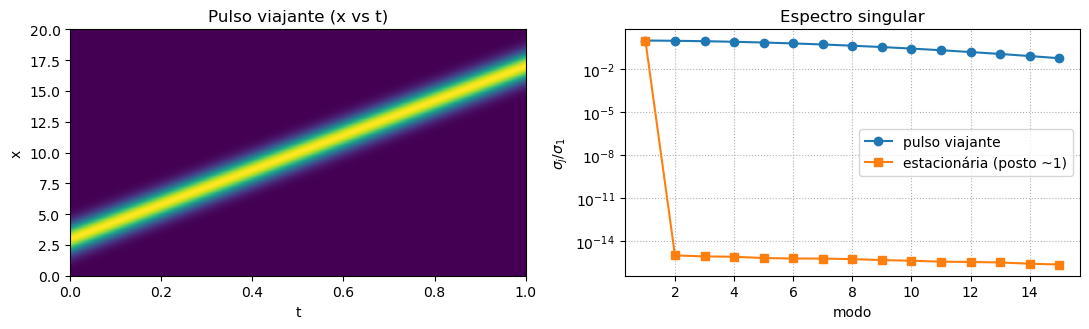

In [11]:
# Comparamos dois fenômenos no plano espaço-tempo (linha = posição x, coluna = tempo t):
# (1) um pulso localizado que VIAJA, e (2) uma oscilação ESTACIONÁRIA (padrão fixo que pulsa).
nxw, mw = 200, 200
xw = np.linspace(0, 20, nxw)     # posições no espaço
tw = np.linspace(0, 1, mw)       # instantes no tempo

centros = 3 + 14*tw              # posição do centro do pulso em cada instante (ele atravessa)

# Construímos a matriz (x, t) por BROADCASTING:
# xw[:, None] é uma COLUNA (nxw, 1) e centros[None, :] é uma LINHA (1, mw);
# a subtração combina as duas e gera a grade (nxw, mw): em cada ponto (x, t),
# a distância do x ao centro do pulso naquele t. A gaussiana disso é o pulso viajante.
viajante = np.exp(-((xw[:, None] - centros[None, :])**2) / (2*0.8**2))

# Oscilação estacionária: um pulso FIXO em x=10 multiplicado por cos(t).
# É um produto (função só de x) * (função só de t) -> matriz de posto 1.
estacionaria = np.exp(-((xw[:, None]-10)**2)/(2*0.8**2)) * np.cos(2*np.pi*tw)[None, :]

# Olhamos o posto efetivo pelos valores singulares de cada matriz.
s_via = np.linalg.svd(viajante, compute_uv=False)
s_est = np.linalg.svd(estacionaria, compute_uv=False)

# Quantos sigma passam de 1% do maior? (s_xxx > 0.01*s_xxx[0]) é uma máscara
# booleana; somar True=1/False=0 conta quantos modos são "relevantes".
print("pulso viajante: nº de sigma > 1% do máximo =", int(np.sum(s_via > 0.01*s_via[0])), "(posto alto)")
print("oscilação estacionária: nº de sigma > 1% do máximo =", int(np.sum(s_est > 0.01*s_est[0])), "(posto ~1)")

fig, (axA, axB) = plt.subplots(1, 2, figsize=(11, 3.4))

# Painel A: o pulso viajante no plano (x vs t) — a faixa diagonal mostra o pulso atravessando.
axA.imshow(viajante, origin="lower", aspect="auto", cmap="viridis",
           extent=[tw[0], tw[-1], xw[0], xw[-1]])
axA.set_title("Pulso viajante (x vs t)")
axA.set_xlabel("t")
axA.set_ylabel("x")

# Painel B: os espectros singulares normalizados (sigma_j / sigma_1). O do pulso
# viajante decai devagar (precisa de muitos modos); o estacionário despenca (posto ~1).
axB.semilogy(range(1, 16), s_via[:15]/s_via[0], "o-", label="pulso viajante")
axB.semilogy(range(1, 16), s_est[:15]/s_est[0]+1e-16, "s-", label="estacionária (posto ~1)")
axB.set_xlabel("modo")
axB.set_ylabel(r"$\sigma_j/\sigma_1$")
axB.legend()
axB.grid(True, ls=":")
axB.set_title("Espectro singular")

plt.tight_layout()
plt.show()

## Síntese da aula

- **POD = SVD de snapshots.** Separe média e flutuações $X'=X-\bar{\mathbf{u}}\mathbf{1}^T$; a SVD
  dá modos espaciais $\boldsymbol\phi_j$ (colunas de $U$), coeficientes temporais $A=\Sigma V^T$ e
  energia modal $E_j=\sigma_j^2/\sum_\ell\sigma_\ell^2$.
- Numa esteira periódica, os dois primeiros modos formam um **par oscilatório** em quadratura, com
  **órbita circular** em $(a_1,a_2)$ — dinâmica dominante de baixa dimensão.
- O **método dos snapshots** ($C_t=X'^TX'$) torna a POD viável quando $n\gg m$.

## Limitações a discutir

- POD é **linear**: variedades curvas e **ondas viajantes** exigem muitos modos.
- **Energia ≠ importância**: um modo de baixa energia pode reger instabilidade/transição.
- Os modos **dependem dos dados** (regime amostrado).
- Em malha **não uniforme**, o produto interno euclidiano distorce a energia — usar matriz de massa $M$.
- Sinais dos modos não são únicos.

## Experimentos sugeridos

1. Aplique POD a $X$ **sem** subtrair a média e veja o 1º modo virar (aproximadamente) o campo
   médio (Exercício 4).
2. Refaça o Exercício 3 ($\sigma=(30,20,5,2,1)$): energia de cada modo e acumulada dos 2 primeiros.
3. Varie a frequência/ruído da esteira e observe a energia dos 2 primeiros modos.
4. Aumente a velocidade $c$ da onda viajante e veja o espectro singular achatar ainda mais.

*Próxima aula (Aula 8): **modelos de ordem reduzida** — projetar a dinâmica no subespaço dos modos
POD e medir reconstrução e erro (consolidação de SVD/PCA/POD/ROM).*